# 15-3 · Valores Influyentes y Distancia de Cook

Un **valor influyente** es una observación cuya presencia o ausencia cambia significativamente el modelo de regresión. La **distancia de Cook** cuantifica esta influencia.

En este notebook:
1. Entendemos la diferencia entre outlier, leverage e influencia
2. Calculamos la distancia de Cook
3. Identificamos observaciones influyentes
4. Demostramos el impacto real de eliminar un punto influyente
5. Comparamos con DFFITS (otra métrica de influencia)

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv("../data/housing.csv")
print(f"Filas: {len(df)}")
df.head(3)

Filas: 100


,id,square_meters,age,price,bedrooms,bathrooms,floor,distance_to_center_km,has_garage,build_quality,property_type,neighborhood
0,1,152,33,338200,4,2,1,4.3,1,10,Single Family,El Prado
1,2,142,24,266900,4,3,8,6.6,1,3,Single Family,Las Flores
2,3,64,11,170800,2,1,1,14.0,1,6,Apartment,El Mirador


In [ ]:
# --- Modelo base ---
predictors = [
    "square_meters",
    "bedrooms",
    "bathrooms",
    "build_quality",
    "age",
    "distance_to_center_km",
    "has_garage",
]

X = df[predictors]
y = df["price"]
n, p = X.shape

X_const = sm.add_constant(X)
ols = sm.OLS(y, X_const).fit()
influence = ols.get_influence()

y_pred = ols.fittedvalues
e = ols.resid
std_resid = influence.resid_studentized_internal
leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

print(f"R² = {ols.rsquared:.4f}")
print(f"n = {n}, p = {p}")

R² = 0.8713
n = 100, p = 7


## 1 · Outlier + Leverage = Influencia

La influencia de una observación depende de **dos factores combinados**:

```
  Influencia = f(Residuo, Leverage)
```

| | Leverage bajo | Leverage alto |
|---|---|---|
| **Residuo bajo** | ✅ Inofensivo | ✅ Sigue la tendencia |
| **Residuo alto** | ⚠️ Outlier sin poder | 🚨 **Influyente** |

> 👈 Solo cuando una observación tiene **ambos** (alto residuo + alto leverage) es realmente influyente.

## 2 · Distancia de Cook (*Cook's Distance*)

La distancia de Cook mide cuánto cambian **todas** las predicciones si eliminamos la observación $i$:

$$D_i = \frac{\sum_{j=1}^{n}(\hat{y}_j - \hat{y}_{j(i)})^2}{p \cdot MSE}$$

Forma computacional equivalente (sin reajustar $n$ veces):

$$D_i = \frac{r_i^2}{p} \cdot \frac{h_{ii}}{1 - h_{ii}}$$

donde $r_i$ es el residuo estandarizado y $h_{ii}$ el leverage.

| Umbral | Interpretación |
|--------|----------------|
| $D_i > 4/n$ | ⚠️ Investigar |
| $D_i > 1$ | 🚨 Muy influyente (raro, pero grave) |

In [3]:
cook_threshold = 4 / n
influential_mask = cooks_d > cook_threshold
n_influential = np.sum(influential_mask)

print(f"Umbral de Cook: 4/n = 4/{n} = {cook_threshold:.4f}")
print(
    f"Observaciones influyentes: {n_influential} de {n} ({100 * n_influential / n:.0f}%)\n"
)

# Desglose: ¿de dónde viene la influencia?
top5 = np.argsort(cooks_d)[-5:][::-1]
print(
    f"{'Obs':>5} {'Cook D':>10} {'|Std Res|':>10} {'Leverage':>10} {'Fuente principal':>20}"
)
print("-" * 58)
lev_threshold = 2 * (p + 1) / n
for i in top5:
    is_outlier = abs(std_resid[i]) > 2
    is_high_lev = leverage[i] > lev_threshold
    if is_outlier and is_high_lev:
        source = "🚨 Ambos"
    elif is_outlier:
        source = "Residuo alto"
    elif is_high_lev:
        source = "Leverage alto"
    else:
        source = "Combinación moderada"
    flag = " ⚠️" if cooks_d[i] > cook_threshold else ""
    print(
        f"{i:>5d} {cooks_d[i]:>10.4f} {abs(std_resid[i]):>10.2f} {leverage[i]:>10.4f} {source:>20s}{flag}"
    )

Umbral de Cook: 4/n = 4/100 = 0.0400
Observaciones influyentes: 4 de 100 (4%)

  Obs     Cook D  |Std Res|   Leverage     Fuente principal
----------------------------------------------------------
   12     0.0791       2.53     0.0899         Residuo alto ⚠️
   14     0.0557       1.60     0.1475 Combinación moderada ⚠️
   44     0.0446       1.36     0.1625        Leverage alto ⚠️
   31     0.0432       1.79     0.0973 Combinación moderada ⚠️
   45     0.0363       1.82     0.0803 Combinación moderada


## 3 · Visualización

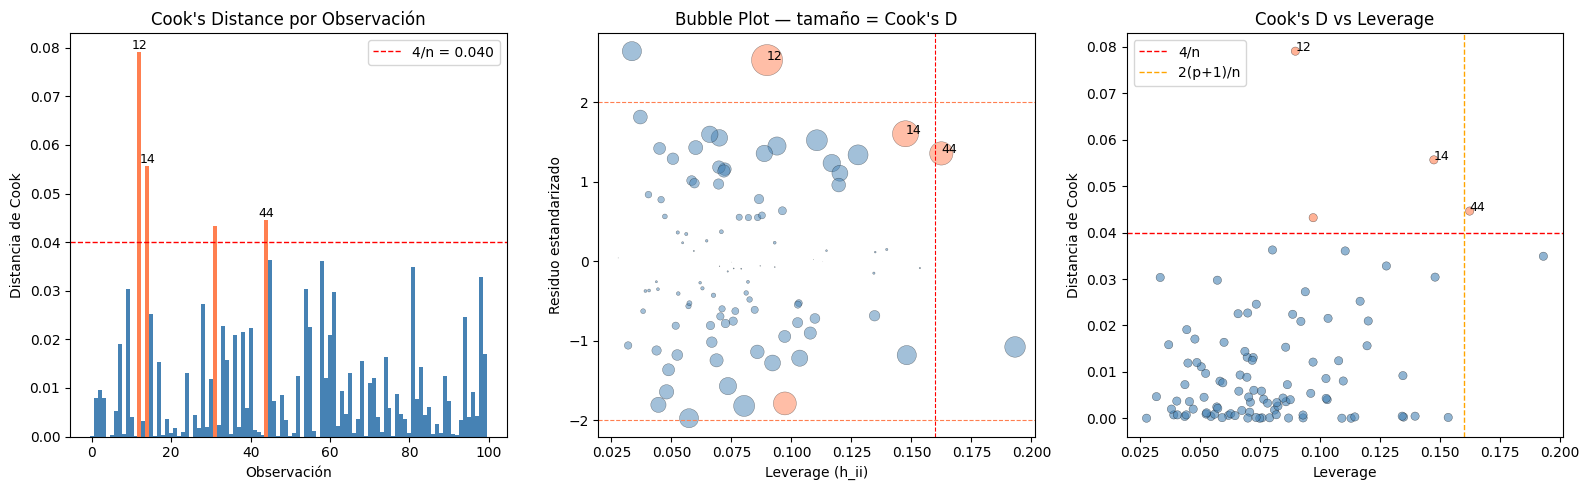

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- 1. Cook's Distance bar ---
ax = axes[0]
colors = ["coral" if d > cook_threshold else "steelblue" for d in cooks_d]
ax.bar(range(n), cooks_d, color=colors, edgecolor="none", width=1.0)
ax.axhline(
    y=cook_threshold,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"4/n = {cook_threshold:.3f}",
)
for i in top5[:3]:
    if cooks_d[i] > cook_threshold:
        ax.annotate(str(i), (i, cooks_d[i]), fontsize=9, ha="center", va="bottom")
ax.set_xlabel("Observación")
ax.set_ylabel("Distancia de Cook")
ax.set_title("Cook's Distance por Observación")
ax.legend()

# --- 2. Bubble plot ---
ax = axes[1]
sizes = 500 * cooks_d / cooks_d.max()
colors2 = ["coral" if d > cook_threshold else "steelblue" for d in cooks_d]
ax.scatter(
    leverage, std_resid, s=sizes, c=colors2, alpha=0.5, edgecolors="k", linewidth=0.3
)
ax.axhline(y=2, color="coral", linestyle="--", linewidth=0.8)
ax.axhline(y=-2, color="coral", linestyle="--", linewidth=0.8)
ax.axvline(x=lev_threshold, color="red", linestyle="--", linewidth=0.8)
for i in top5[:3]:
    ax.annotate(str(i), (leverage[i], std_resid[i]), fontsize=9, ha="left")
ax.set_xlabel("Leverage (h_ii)")
ax.set_ylabel("Residuo estandarizado")
ax.set_title("Bubble Plot — tamaño = Cook's D")

# --- 3. Cook's D vs Leverage con contornos ---
ax = axes[2]
ax.scatter(leverage, cooks_d, c=colors, alpha=0.6, edgecolors="k", linewidth=0.3)
ax.axhline(y=cook_threshold, color="red", linestyle="--", linewidth=1, label=f"4/n")
ax.axvline(
    x=lev_threshold, color="orange", linestyle="--", linewidth=1, label=f"2(p+1)/n"
)
for i in top5[:3]:
    if cooks_d[i] > cook_threshold:
        ax.annotate(str(i), (leverage[i], cooks_d[i]), fontsize=9, ha="left")
ax.set_xlabel("Leverage")
ax.set_ylabel("Distancia de Cook")
ax.set_title("Cook's D vs Leverage")
ax.legend()

plt.tight_layout()
plt.show()

## 4 · Demostración: impacto real de un punto influyente

La mejor forma de entender la influencia es **ver qué pasa** cuando eliminamos el punto más influyente:

In [ ]:
most_influential = np.argmax(cooks_d)
print(f"Punto más influyente: observación {most_influential}")
print(f"  Cook's D: {cooks_d[most_influential]:.4f}")
print(f"  Leverage: {leverage[most_influential]:.4f}")
print(f"  Std Resid: {std_resid[most_influential]:.2f}")
print(
    f"  Price: ${y[most_influential]:,.0f} (predicho: ${y_pred[most_influential]:,.0f})\n"
)

# Reajustar sin el punto influyente
mask = np.ones(n, dtype=bool)
mask[most_influential] = False
ols_clean = sm.OLS(y[mask], X_const[mask]).fit()

# Comparar coeficientes
print(
    f"{'Predictor':>25s} {'Original':>12s} {'Sin obs ' + str(most_influential):>15s} {'Cambio %':>10s}"
)
print("-" * 65)
names = ["intercepto"] + predictors
for name, c1, c2 in zip(names, ols.params, ols_clean.params):
    pct = 100 * (c2 - c1) / abs(c1) if abs(c1) > 0.01 else 0
    marker = " 🔴" if abs(pct) > 10 else ""
    print(f"{name:>25s} {c1:>12,.1f} {c2:>12,.1f} {pct:>9.1f}%{marker}")

print(f"\n{'R²':>25s} {ols.rsquared:>12.4f} {ols_clean.rsquared:>12.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Coeficientes comparados ---
ax = axes[0]
coef_orig = ols.params[1:]
coef_clean = ols_clean.params[1:]
x_pos = np.arange(len(predictors))
width = 0.35
ax.barh(
    x_pos - width / 2, coef_orig, width, color="steelblue", label="Con punto influyente"
)
ax.barh(
    x_pos + width / 2, coef_clean, width, color="coral", label="Sin punto influyente"
)
ax.set_yticks(x_pos)
ax.set_yticklabels(predictors)
ax.set_xlabel("Coeficiente")
ax.set_title(f"Impacto de eliminar obs {most_influential}")
ax.legend(fontsize=9)
ax.axvline(x=0, color="gray", linewidth=0.5)

# --- Predicciones comparadas ---
ax = axes[1]
y_pred_clean = ols_clean.predict(X_const[mask])
ax.scatter(
    y_pred[mask],
    y_pred_clean,
    color="steelblue",
    alpha=0.5,
    edgecolors="k",
    linewidth=0.3,
    label="Resto de obs",
)
lims = [min(y_pred.min(), y_pred_clean.min()), max(y_pred.max(), y_pred_clean.max())]
ax.plot(lims, lims, "k--", linewidth=1, label="Sin cambio")
ax.set_xlabel("Predicción (modelo original)")
ax.set_ylabel("Predicción (sin punto influyente)")
ax.set_title("¿Cuánto cambian las predicciones?")
ax.legend()

plt.tight_layout()
plt.show()

# RMSE del cambio
rmse_change = np.sqrt(np.mean((y_pred[mask] - y_pred_clean) ** 2))
print(f"RMSE del cambio en predicciones: ${rmse_change:,.0f}")

## 5 · DFFITS — otra métrica de influencia

**DFFITS** mide cuánto cambia la predicción de la observación $i$ cuando se excluye del ajuste:

$$DFFITS_i = \frac{\hat{y}_i - \hat{y}_{i(i)}}{s_{(i)} \cdot \sqrt{h_{ii}}}$$

Umbral: $|DFFITS| > 2\sqrt{(p+1)/n}$

La diferencia con Cook's D:
- Cook's D mide el cambio en **todas** las predicciones
- DFFITS mide el cambio en la predicción **de esa misma observación**

In [ ]:
dffits = influence.dffits[0]
dffits_threshold = 2 * np.sqrt((p + 1) / n)

print(f"Umbral DFFITS: 2*sqrt((p+1)/n) = {dffits_threshold:.4f}\n")

# Comparar Cook's D vs DFFITS para los top 5
print(f"{'Obs':>5} {'Cook D':>10} {'DFFITS':>10} {'|DFFITS|>umbral':>16}")
print("-" * 44)
for i in top5:
    flag = "🚨" if abs(dffits[i]) > dffits_threshold else "✅"
    print(f"{i:>5d} {cooks_d[i]:>10.4f} {dffits[i]:>10.4f} {flag:>16s}")

# ¿Coinciden en identificar los mismos puntos?
cook_set = set(np.where(cooks_d > cook_threshold)[0])
dffits_set = set(np.where(np.abs(dffits) > dffits_threshold)[0])
print(f"\nInfluyentes por Cook's D: {sorted(cook_set)}")
print(f"Influyentes por DFFITS:   {sorted(dffits_set)}")
print(f"En común:                 {sorted(cook_set & dffits_set)}")

## 6 · ¿Qué hacer con valores influyentes?

| Paso | Acción |
|------|--------|
| 1️⃣ | **Identificar** con Cook's D > 4/n |
| 2️⃣ | **Investigar**: ¿es un error de datos? ¿un caso genuinamente especial? |
| 3️⃣ | **Comparar** modelo con y sin el punto |
| 4️⃣ | **Reportar** ambos resultados si difieren significativamente |
| 5️⃣ | **No eliminar** automáticamente — documentar la decisión |

> 👈 Un punto influyente puede ser la observación **más informativa** del dataset. Eliminarlo puede sesgar los resultados más que dejarlo.

## 7 · Resumen

| Concepto | Detalle |
|----------|--------|
| **Influencia** | = Outlier × Leverage combinados |
| **Cook's Distance** | Cambio en **todas** las predicciones al eliminar obs $i$ |
| **DFFITS** | Cambio en la predicción **de obs $i$** al eliminarla |
| **Umbral Cook's D** | $D_i > 4/n$ (investigar), $D_i > 1$ (grave) |
| **Umbral DFFITS** | $|DFFITS_i| > 2\sqrt{(p+1)/n}$ |
| **statsmodels** | `influence.cooks_distance[0]`, `influence.dffits[0]` |
| **Regla de oro** | Investigar, no eliminar ciegamente |